# Тема 1: Моделирование геометрической вероятности


> **Задание:** Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

---



## Задача "монетка на квадратной плитке"
На пол, выложенный квадратной плиткой со стороной $A = 10\text{ см}$, падает круглая монетка радиуса $R = 2\text{ см}$. Найти вероятность того, что монетка полностью окажется внутри одной плитки и не пересечёт ни один из её краёв (швов).



### Теоретический расчет

Рассмотрим событие **$A$** - монетка полностью упала на одну плитку и не задела швы.

По формуле геометрической вероятности делим благоприятную площадь $S_A$ на всю площадь плитки $S$:

$$P(A) = \frac{S_A}{S}$$

*  $S$: размер плитки $10 \times 10\text{ см}$:
  $$S = 10 \cdot 10 = 100\text{ см}^2$$

* $S_A$: чтобы монета радиусом 2 см не задела края, ее центр должен упасть с отступом в 2 см от каждой стороны. Получаем внутренний квадрат со стороной $10 - 2 - 2 = 6\text{ см}$:
  $$S_A = 6 \cdot 6 = 36\text{ см}^2$$


  $$P(A) = \frac{36}{100} = 0.36 \quad (36\%)$$

Экспериментальная вероятность: 0.3605


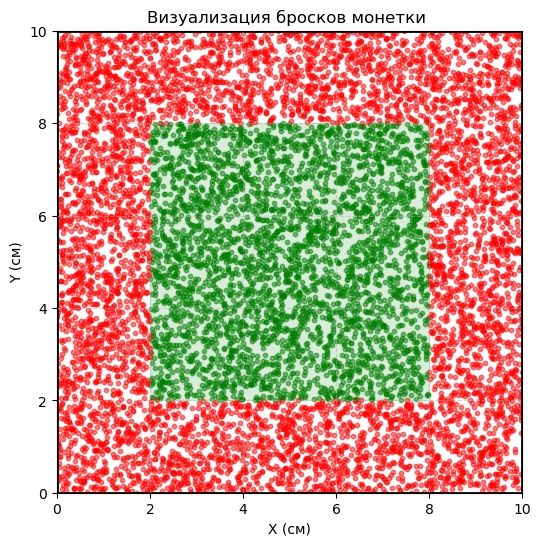

In [12]:
import numpy as np
import matplotlib.pyplot as plt

A = 10.0
R = 2.0
N = 10000

np.random.seed(42)

x = np.random.uniform(0, A, N)
y = np.random.uniform(0, A, N)

is_inside = (x >= R) & (x <= A - R) & (y >= R) & (y <= A - R)

M = np.sum(is_inside)
P_exp = M / N

print(f"Экспериментальная вероятность: {P_exp:.4f}")

plt.figure(figsize=(6, 6))

plt.scatter(x[is_inside], y[is_inside], color='green', alpha=0.5, s=10)
plt.scatter(x[~is_inside], y[~is_inside], color='red', alpha=0.5, s=10)

plt.gca().add_patch(plt.Rectangle((0, 0), A, A, fill=False, edgecolor='black', lw=2))
plt.gca().add_patch(plt.Rectangle((R, R), A - 2*R, A - 2*R, fill=True, color='green', alpha=0.15))

plt.xlim(0, A)
plt.ylim(0, A)
plt.title('Визуализация бросков монетки ')
plt.xlabel('X (см)')
plt.ylabel('Y (см)')


plt.grid(True, linestyle='--', alpha=0.5)

plt.show()